<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_self_repair_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

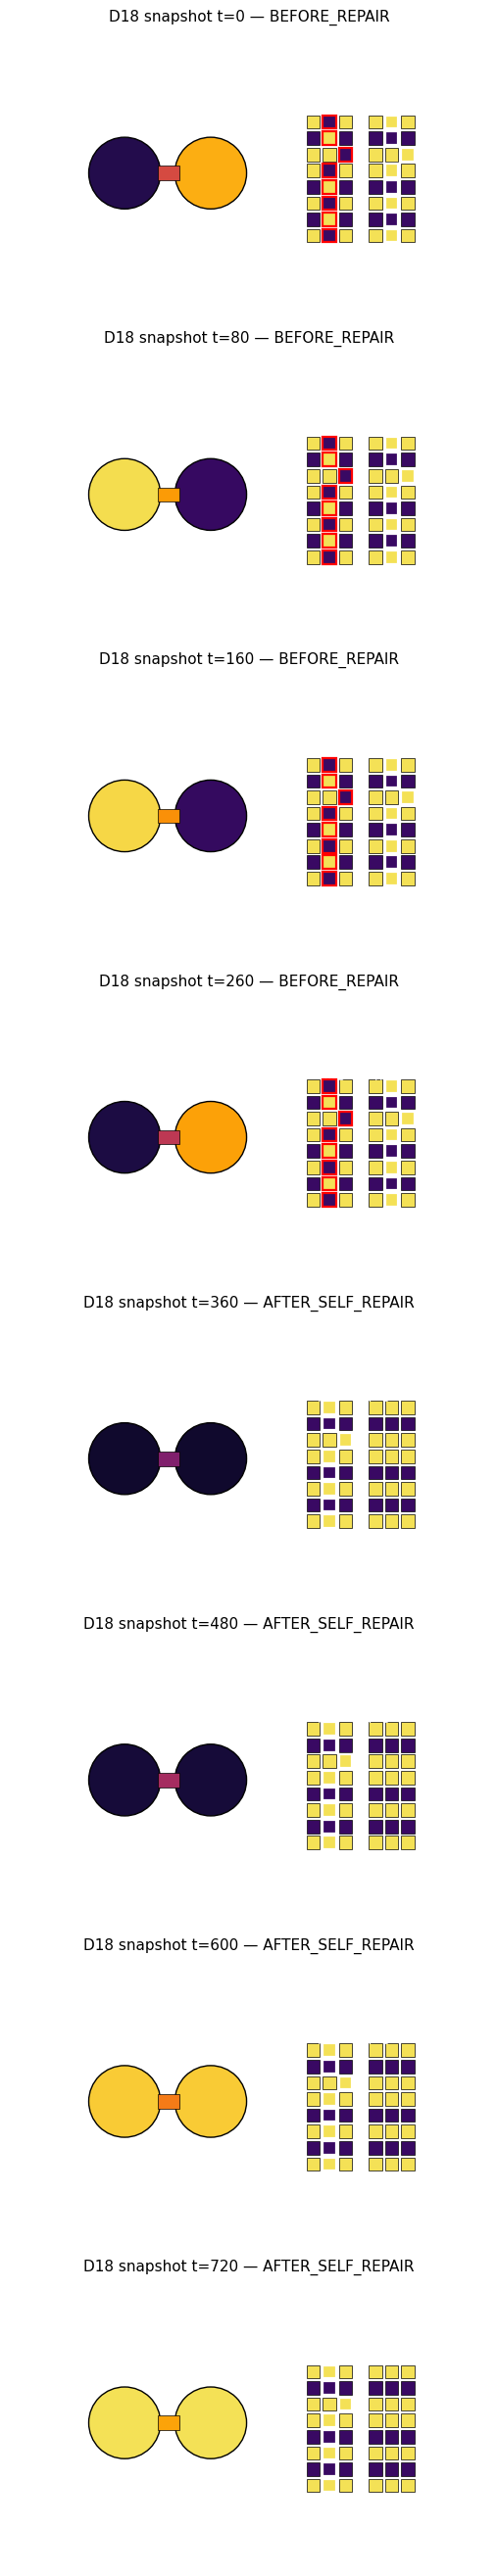

STATE: SELF_REPAIR_LOCKED
input sequence:        10110101
raw decoded copies:    101010110101010101010101
corrected sequence:    10110101
repaired encoded seq:  111000111111000111000111
damaged copies:        8
copies repaired:       8
raw copy accuracy:     0.667
corrected accuracy:    1.0
repair accuracy:       1.0

Copy-level self-repair table:


,STATE,COPY_INDEX,SOURCE_BIT_INDEX,ORIGINAL_ENCODED_BIT,RAW_DECODED_BIT,COPY_WAS_DAMAGED,REPAIRED_BIT,REPAIR_CHANGED_COPY,REPAIRED_MATCH
0,D18_SELF_REPAIR_MEMORY,0,0,1,1,0,1,0,1
1,D18_SELF_REPAIR_MEMORY,1,0,1,0,1,1,1,1
2,D18_SELF_REPAIR_MEMORY,2,0,1,1,0,1,0,1
3,D18_SELF_REPAIR_MEMORY,3,1,0,0,0,0,0,1
4,D18_SELF_REPAIR_MEMORY,4,1,0,1,1,0,1,1
5,D18_SELF_REPAIR_MEMORY,5,1,0,0,0,0,0,1
6,D18_SELF_REPAIR_MEMORY,6,2,1,1,0,1,0,1
7,D18_SELF_REPAIR_MEMORY,7,2,1,1,0,1,0,1
8,D18_SELF_REPAIR_MEMORY,8,2,1,0,1,1,1,1
9,D18_SELF_REPAIR_MEMORY,9,3,1,1,0,1,0,1



Majority repair table:


,STATE,BIT_INDEX,INPUT_BIT,RAW_COPIES,VOTE_SUM,CORRECTED_BIT,MATCH
0,D18_SELF_REPAIR_MEMORY,0,1,101,2,1,1
1,D18_SELF_REPAIR_MEMORY,1,0,010,1,0,1
2,D18_SELF_REPAIR_MEMORY,2,1,110,2,1,1
3,D18_SELF_REPAIR_MEMORY,3,1,101,2,1,1
4,D18_SELF_REPAIR_MEMORY,4,0,010,1,0,1
5,D18_SELF_REPAIR_MEMORY,5,1,101,2,1,1
6,D18_SELF_REPAIR_MEMORY,6,0,010,1,0,1
7,D18_SELF_REPAIR_MEMORY,7,1,101,2,1,1



Summary:


,STATE,RESULT,INPUT_SEQUENCE,RAW_DECODED_COPIES,CORRECTED_SEQUENCE,REPAIRED_ENCODED_SEQUENCE,COPIES_PER_BIT,DAMAGED_COPIES,COPIES_REPAIRED,RAW_COPY_ACCURACY,CORRECTED_ACCURACY,REPAIR_ACCURACY,THRESHOLD
0,D18_SELF_REPAIR_MEMORY,SELF_REPAIR_LOCKED,10110101,101010110101010101010101,10110101,111000111111000111000111,3,8,8,0.667,1.0,1.0,0.45


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# ============================================================
# D18_SELF_REPAIR_MEMORY
# Field memory self-repair after majority correction
#
# Goal:
# input sequence
# -> redundant wave copies
# -> damaged copies
# -> majority correction
# -> write corrected value back into damaged copies
# -> repaired memory state
# ============================================================

np.random.seed(18)

STATE = "D18_SELF_REPAIR_MEMORY"

input_sequence = "10110101"
copies_per_bit = 3
decode_threshold = 0.45

# Same damage pattern style as D17:
# one damaged copy per bit group, but never enough to break majority.
damaged_copy_indexes = [1, 4, 8, 10, 13, 16, 19, 22]


def encode_repetition(seq, copies=3):
    encoded = []
    source = []
    for bit_index, bit in enumerate(seq):
        for _ in range(copies):
            encoded.append(int(bit))
            source.append(bit_index)
    return encoded, source


def majority_vote(bits):
    return 1 if sum(bits) >= 2 else 0


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


encoded_bits, source_bit_indexes = encode_repetition(input_sequence, copies_per_bit)

raw_bits = encoded_bits.copy()
for idx in damaged_copy_indexes:
    raw_bits[idx] = 1 - raw_bits[idx]

# Simulated received intensity for each raw copy
received_means = []
for i, bit in enumerate(raw_bits):
    if bit == 1:
        value = 0.64 + np.random.normal(0, 0.035)
    else:
        value = 0.25 + np.random.normal(0, 0.035)
    received_means.append(float(np.clip(value, 0.0, 1.0)))

raw_decoded_bits = [1 if v >= decode_threshold else 0 for v in received_means]

# Majority correction per original bit
corrected_bits = []
repair_rows = []

for bit_index in range(len(input_sequence)):
    start = bit_index * copies_per_bit
    end = start + copies_per_bit

    group = raw_decoded_bits[start:end]
    corrected = majority_vote(group)

    corrected_bits.append(corrected)

    repair_rows.append({
        "STATE": STATE,
        "BIT_INDEX": bit_index,
        "INPUT_BIT": int(input_sequence[bit_index]),
        "RAW_COPIES": bits_to_string(group),
        "VOTE_SUM": int(sum(group)),
        "CORRECTED_BIT": corrected,
        "MATCH": int(corrected == int(input_sequence[bit_index]))
    })

corrected_sequence = bits_to_string(corrected_bits)

# Self-repair write-back:
# all copies in a group are rewritten to the corrected bit
repaired_bits = []
for bit in corrected_bits:
    repaired_bits.extend([bit] * copies_per_bit)

repaired_encoded_sequence = bits_to_string(repaired_bits)

# Tables
copy_rows = []
for i in range(len(encoded_bits)):
    copy_rows.append({
        "STATE": STATE,
        "COPY_INDEX": i,
        "SOURCE_BIT_INDEX": source_bit_indexes[i],
        "ORIGINAL_ENCODED_BIT": encoded_bits[i],
        "RAW_DECODED_BIT": raw_decoded_bits[i],
        "COPY_WAS_DAMAGED": int(i in damaged_copy_indexes),
        "REPAIRED_BIT": repaired_bits[i],
        "REPAIR_CHANGED_COPY": int(raw_decoded_bits[i] != repaired_bits[i]),
        "REPAIRED_MATCH": int(repaired_bits[i] == encoded_bits[i])
    })

df_copies = pd.DataFrame(copy_rows)
df_repair = pd.DataFrame(repair_rows)

raw_copy_accuracy = float(np.mean(np.array(raw_decoded_bits) == np.array(encoded_bits)))
corrected_accuracy = float(np.mean(np.array(corrected_bits) == np.array([int(x) for x in input_sequence])))
repair_accuracy = float(np.mean(np.array(repaired_bits) == np.array(encoded_bits)))
copies_repaired = int(np.sum(np.array(raw_decoded_bits) != np.array(repaired_bits)))

result = "SELF_REPAIR_LOCKED" if corrected_accuracy == 1.0 and repair_accuracy == 1.0 else "SELF_REPAIR_PARTIAL"

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "INPUT_SEQUENCE": input_sequence,
    "RAW_DECODED_COPIES": bits_to_string(raw_decoded_bits),
    "CORRECTED_SEQUENCE": corrected_sequence,
    "REPAIRED_ENCODED_SEQUENCE": repaired_encoded_sequence,
    "COPIES_PER_BIT": copies_per_bit,
    "DAMAGED_COPIES": len(damaged_copy_indexes),
    "COPIES_REPAIRED": copies_repaired,
    "RAW_COPY_ACCURACY": round(raw_copy_accuracy, 3),
    "CORRECTED_ACCURACY": round(corrected_accuracy, 3),
    "REPAIR_ACCURACY": round(repair_accuracy, 3),
    "THRESHOLD": decode_threshold
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.72 + 0.20 * intensity)
    return plt.cm.inferno(0.08 + 0.10 * intensity)


def draw_copy_grid(ax, x0, y0, bits, title, damaged=None, repaired=None):
    damaged = set(damaged or [])
    repaired = set(repaired or [])

    cell = 0.28
    gap = 0.06

    ax.text(x0, y0 + 2.65, title, color="white", fontsize=8, ha="left", va="bottom")

    for bit_index in range(len(input_sequence)):
        for copy in range(copies_per_bit):
            idx = bit_index * copies_per_bit + copy
            x = x0 + copy * (cell + gap)
            y = y0 + (len(input_sequence) - 1 - bit_index) * (cell + gap)

            color = bit_color(bits[idx])
            edge = "red" if idx in damaged else "white" if idx in repaired else "black"
            lw = 1.6 if idx in damaged or idx in repaired else 0.5

            rect = Rectangle((x, y), cell, cell, facecolor=color, edgecolor=edge, linewidth=lw)
            ax.add_patch(rect)


def draw_snapshot(ax, t, phase, show_repair=False):
    ax.set_facecolor("black")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect("equal")
    ax.axis("off")

    wave = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    left_bit = 1 if wave > 0.5 else 0
    right_bit = left_bit if show_repair else 1 - left_bit

    left_color = bit_color(left_bit, wave)
    right_color = bit_color(right_bit, wave)

    # Field cells
    ax.add_patch(Circle((2.4, 3.0), 0.75, facecolor=left_color, edgecolor="black", linewidth=1.0))
    ax.add_patch(Circle((4.2, 3.0), 0.75, facecolor=right_color, edgecolor="black", linewidth=1.0))

    # Bridge
    bridge_color = plt.cm.inferno(0.35 + 0.45 * wave)
    ax.add_patch(Rectangle((3.1, 2.85), 0.45, 0.3, facecolor=bridge_color, edgecolor="black", linewidth=0.5))

    # Grids
    if not show_repair:
        draw_copy_grid(ax, 6.2, 1.55, raw_decoded_bits, "damaged copies", damaged=damaged_copy_indexes)
        draw_copy_grid(ax, 7.5, 1.55, repaired_bits, "repair target", repaired=damaged_copy_indexes)
    else:
        draw_copy_grid(ax, 6.2, 1.55, repaired_bits, "repaired copies", repaired=damaged_copy_indexes)
        draw_copy_grid(ax, 7.5, 1.55, encoded_bits, "original target")

    ax.set_title(f"D18 snapshot t={t} — {'AFTER_SELF_REPAIR' if show_repair else 'BEFORE_REPAIR'}", color="black", fontsize=11)


snapshots = [
    (0, 0.00, False),
    (80, 0.18, False),
    (160, 0.35, False),
    (260, 0.55, False),
    (360, 0.72, True),
    (480, 0.90, True),
    (600, 0.10, True),
    (720, 0.28, True),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7, 3.3 * len(snapshots)))

for ax, (t, phase, show_repair) in zip(axes, snapshots):
    draw_snapshot(ax, t, phase, show_repair)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"input sequence:        {input_sequence}")
print(f"raw decoded copies:    {bits_to_string(raw_decoded_bits)}")
print(f"corrected sequence:    {corrected_sequence}")
print(f"repaired encoded seq:  {repaired_encoded_sequence}")
print(f"damaged copies:        {len(damaged_copy_indexes)}")
print(f"copies repaired:       {copies_repaired}")
print(f"raw copy accuracy:     {round(raw_copy_accuracy, 3)}")
print(f"corrected accuracy:    {round(corrected_accuracy, 3)}")
print(f"repair accuracy:       {round(repair_accuracy, 3)}")

print("\nCopy-level self-repair table:")
display(df_copies)

print("\nMajority repair table:")
display(df_repair)

print("\nSummary:")
display(df_summary)